
Model: Logistic L2
Accuracy: 0.8032786885245902
Confusion Matrix:
 [[19  9]
 [ 3 30]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Model: Logistic L1
Accuracy: 0.8032786885245902
Confusion Matrix:
 [[19  9]
 [ 3 30]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Model: SVM
Accuracy: 0.7868852459016393
Confusion Matrix:
 [[18 10]
 [ 3 30]]
Classification Report:
               precisi

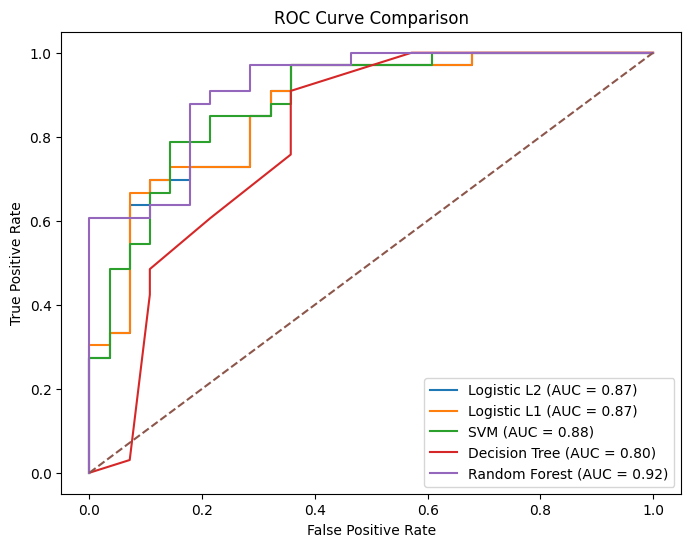

In [2]:
# ==========================
# IMPORT LIBRARIES
# ==========================

import numpy as np                      # Numerical operations
import pandas as pd                     # Data handling
import matplotlib.pyplot as plt         # Plotting graphs

from sklearn.model_selection import train_test_split  # Split dataset
from sklearn.preprocessing import StandardScaler       # Feature scaling

from sklearn.linear_model import LogisticRegression    # Logistic Regression
from sklearn.svm import SVC                            # Support Vector Machine
from sklearn.tree import DecisionTreeClassifier        # Decision Tree
from sklearn.ensemble import RandomForestClassifier    # Random Forest

from sklearn.metrics import (
    accuracy_score,            # Accuracy metric
    confusion_matrix,          # Confusion matrix
    classification_report,     # Precision, Recall, F1-score
    roc_curve,                 # ROC curve
    auc                        # Area Under Curve
)

# ==========================
# LOAD DATASET
# ==========================

data = pd.read_csv("heart.csv")   # Load heart disease dataset

X = data.drop("target", axis=1).values   # Features (input variables)
y = data["target"].values                # Target (output class)

# ==========================
# TRAIN / TEST SPLIT
# ==========================

# Split data into 80% training and 20% testing
# stratify=y ensures equal class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================
# FEATURE SCALING
# ==========================

scaler = StandardScaler()  # Standardization (mean=0, std=1)

# Fit scaler only on training data (to avoid data leakage)
X_train = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test = scaler.transform(X_test)

# ==========================
# LOGISTIC REGRESSION (L2)
# ==========================

# L2 regularization (Ridge)
# penalty='l2' helps prevent overfitting
# C controls strength of regularization
log_model = LogisticRegression(
    penalty="l2",
    C=2.0,
    max_iter=1000,
    random_state=42
)

# ==========================
# LOGISTIC REGRESSION (L1)
# ==========================

# L1 regularization (Lasso)
# Performs feature selection (some weights become zero)
log_l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",  # Required for L1
    C=2.0,
    max_iter=1000,
    random_state=42
)

# ==========================
# SUPPORT VECTOR MACHINE
# ==========================

# Linear kernel SVM
# C parameter controls regularization
# Smaller C → stronger regularization
svm_model = SVC(
    kernel="linear",
    C=1.0,
    probability=True,   # Needed for ROC curve
    random_state=42
)

# ==========================
# DECISION TREE
# ==========================

# max_depth limits tree size
# Prevents overfitting
# min_samples_split avoids very small splits
tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

# ==========================
# RANDOM FOREST
# ==========================

# Ensemble of many decision trees
# n_estimators = number of trees
# Reduces overfitting by averaging
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# ==========================
# STORE MODELS
# ==========================

models = {
    "Logistic L2": log_model,
    "Logistic L1": log_l1_model,
    "SVM": svm_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

# Dictionary to store results
results = {}

# ==========================
# TRAIN AND EVALUATE MODELS
# ==========================

for name, model in models.items():

    # Train model on training data
    model.fit(X_train, y_train)

    # Predict class labels
    y_pred = model.predict(X_test)

    # Get probability scores for ROC curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Store evaluation results
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred),
        "y_prob": y_prob
    }

# ==========================
# PRINT RESULTS
# ==========================

for name in results:
    print("\n====================")
    print("Model:", name)
    print("Accuracy:", results[name]["accuracy"])
    print("Confusion Matrix:\n", results[name]["confusion_matrix"])
    print("Classification Report:\n", results[name]["classification_report"])

# ==========================
# ROC CURVE COMPARISON
# ==========================

plt.figure(figsize=(8,6))

for name in results:

    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])

    # Calculate AUC score
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()